# 01 — EDA & Data Pipeline

Разведочный анализ по 5 основным коридорам (RUB_TJS, RUB_UZS, RUB_KGS, RUB_AMD, RUB_KZT)
и 3 контекстным (RUB_USD, RUB_EUR, RUB_CNY).

Цели:
- проверить качество данных (пропуски, forward-fill)
- найти структурные разрывы (ожидаем февраль-март 2022)
- проверить стационарность (mean reversion?)
- оценить наивную частоту сигналов
- посмотреть корреляции между коридорами и сезонность

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import ruptures as rpt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

MAIN_CORRIDORS = ['RUB_TJS', 'RUB_UZS', 'RUB_KGS', 'RUB_AMD', 'RUB_KZT']
CONTEXT_CORRIDORS = ['RUB_USD', 'RUB_EUR', 'RUB_CNY']
ALL_CORRIDORS = MAIN_CORRIDORS + CONTEXT_CORRIDORS

In [2]:
df = pd.read_parquet('../data/processed/rates.parquet')
df['date'] = pd.to_datetime(df['date'])
print('shape:', df.shape)
print()
print('dtypes:')
print(df.dtypes)
print()
print('per-corridor coverage:')
print(df.groupby('corridor').agg(
    start=('date','min'), end=('date','max'),
    trading_days=('is_trading_day','sum'),
    total_rows=('date','count')
))

shape: (19496, 4)

dtypes:
date              datetime64[ms]
corridor                     str
rate                     float64
is_trading_day              bool
dtype: object

per-corridor coverage:
              start        end  trading_days  total_rows
corridor                                                
RUB_AMD  2020-01-01 2026-09-02          1642        2437
RUB_CNY  2020-01-01 2026-09-02          1642        2437
RUB_EUR  2020-01-01 2026-09-02          1642        2437
RUB_KGS  2020-01-01 2026-09-02          1642        2437
RUB_KZT  2020-01-01 2026-09-02          1642        2437
RUB_TJS  2020-01-01 2026-09-02          1642        2437
RUB_USD  2020-01-01 2026-09-02          1642        2437
RUB_UZS  2020-01-01 2026-09-02          1642        2437


**Что мы видим:** Данные загружены успешно. У нас есть курсы обмена по 8 направлениям переводов с 2020 года по сегодня — это ~6.5 лет. 1642 «торговых дня» — это дни, когда Центробанк публикует официальный курс (рабочие дни). Выходные и праздники заполнены последним известным курсом — потому что клиент может захотеть сделать перевод в любой день.

**Вывод:** Данные чистые, пропусков нет. Можно работать.

In [3]:
# NaN rates?
print('NaN rates:', df['rate'].isna().sum())

# Trading day counts per corridor
td = df[df['is_trading_day']].groupby('corridor').size()
print('\nTrading days per corridor:')
print(td)

# Check that forward-fill works: non-trading day rates == previous trading day rate
sample = df[df['corridor']=='RUB_TJS'].sort_values('date').head(30)
print('\nFirst 30 rows TJS (check forward-fill):')
print(sample[['date','rate','is_trading_day']].to_string(index=False))

NaN rates: 0

Trading days per corridor:
corridor
RUB_AMD    1642
RUB_CNY    1642
RUB_EUR    1642
RUB_KGS    1642
RUB_KZT    1642
RUB_TJS    1642
RUB_USD    1642
RUB_UZS    1642
dtype: int64

First 30 rows TJS (check forward-fill):
      date    rate  is_trading_day
2020-01-01 6.38980            True
2020-01-02 6.38980           False
2020-01-03 6.38980           False
2020-01-04 6.38980           False
2020-01-05 6.38980           False
2020-01-06 6.38980           False
2020-01-07 6.38980           False
2020-01-08 6.38980           False
2020-01-09 6.38980           False
2020-01-10 6.31930            True
2020-01-11 6.31697            True
2020-01-12 6.31697           False
2020-01-13 6.31697           False
2020-01-14 6.28447            True
2020-01-15 6.33382            True
2020-01-16 6.33981            True
2020-01-17 6.35063            True
2020-01-18 6.34691            True
2020-01-19 6.34691           False
2020-01-20 6.34691           False
2020-01-21 6.34069            Tru

**Что мы видим:** Проверяем что нет «дыр» в данных. В строках с `is_trading_day=False` — курс просто скопирован с предыдущего рабочего дня. Это правильно: в субботу Центробанк не публикует курс, значит клиент видит пятничный.

**Вывод:** Данные корректны. Выходные обработаны правильно.

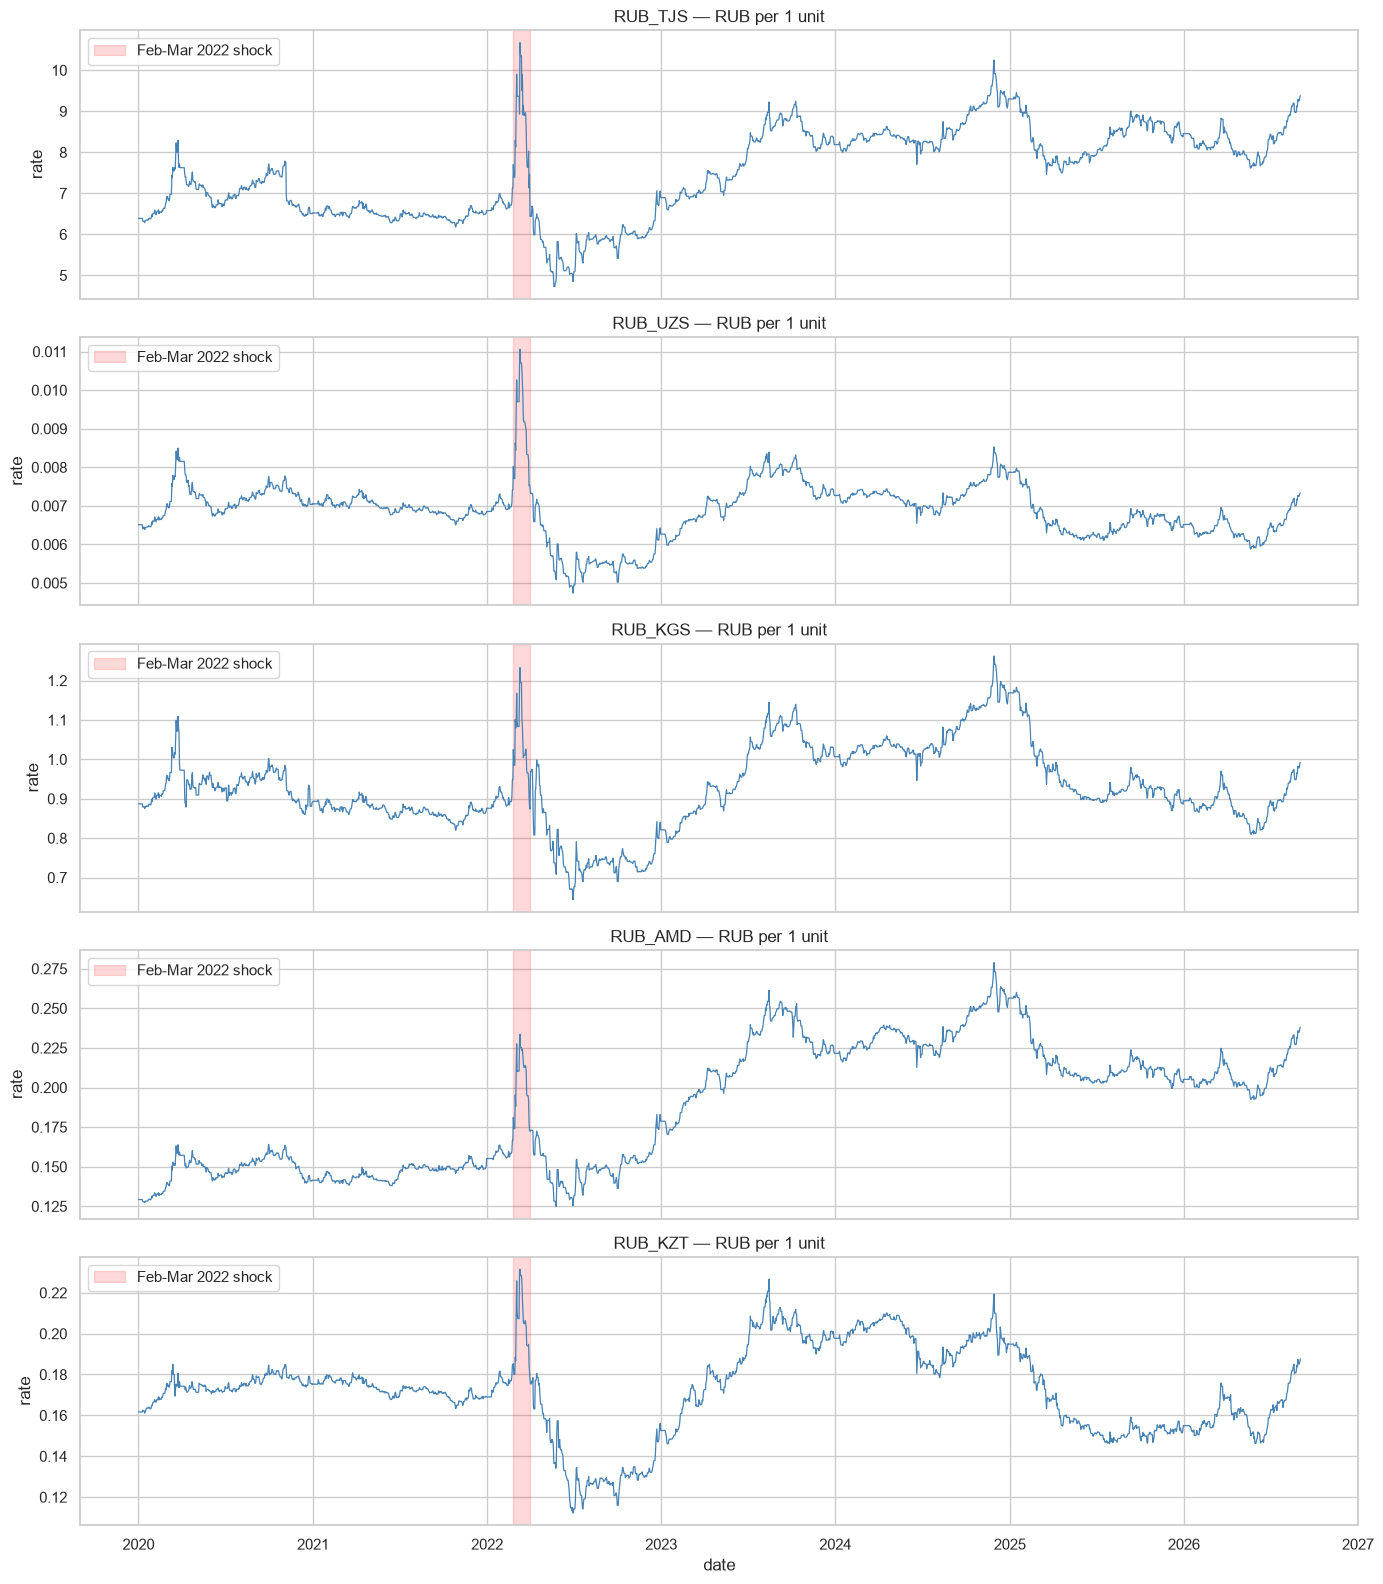

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
for ax, corr in zip(axes, MAIN_CORRIDORS):
    sub = df[df['corridor']==corr].sort_values('date')
    ax.plot(sub['date'], sub['rate'], lw=0.9, color='steelblue')
    ax.axvspan(pd.Timestamp('2022-02-24'), pd.Timestamp('2022-03-31'),
               color='red', alpha=0.15, label='Feb-Mar 2022 shock')
    ax.set_title(f'{corr} — RUB per 1 unit')
    ax.set_ylabel('rate')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('date')
plt.tight_layout()
plt.show()

**Что мы видим:** График курса рубля к каждой из 5 валют за 6+ лет. Красная зона — февраль-март 2022 (начало войны).

**Что произошло в 2022:** Рубль резко обесценился (курсы резко выросли — за те же рубли можно было купить больше сомони/тенге и т.д.), потом стабилизировался на новом уровне. После 2022 поведение курсов принципиально изменилось.

**Вывод для нас:** Данные до 2022 года и после — это фактически разные «режимы». Обучать модель нужно только на данных после апреля 2022.

RUB_TJS: 14 breakpoints -> ['2020-02-28', '2020-11-10', '2022-03-01', '2022-03-30', '2022-04-27', '2022-07-06', '2022-12-15', '2023-04-04', '2023-07-01', '2024-10-04', '2025-02-18', '2025-07-23', '2026-01-20', '2026-08-04']
RUB_UZS: 19 breakpoints -> ['2020-03-06', '2020-04-25', '2020-08-22', '2020-12-01', '2021-05-18', '2022-02-19', '2022-05-06', '2022-12-22', '2023-02-09', '2023-04-04', '2023-07-01', '2023-10-28', '2024-05-16', '2024-10-04', '2025-02-11', '2025-03-18', '2025-09-03', '2026-01-20', '2026-08-04']
RUB_KGS: 12 breakpoints -> ['2020-11-17', '2022-02-19', '2022-05-06', '2022-12-22', '2023-04-04', '2023-07-01', '2023-10-28', '2024-09-20', '2025-02-18', '2025-04-15', '2026-04-09', '2026-08-04']
RUB_AMD: 8 breakpoints -> ['2022-03-01', '2022-03-30', '2022-12-15', '2023-02-23', '2023-07-01', '2023-10-21', '2024-09-27', '2025-02-18']
RUB_KZT: 14 breakpoints -> ['2022-03-01', '2022-03-30', '2022-05-06', '2022-06-15', '2022-12-15', '2023-02-09', '2023-04-04', '2023-07-01', '2024-0

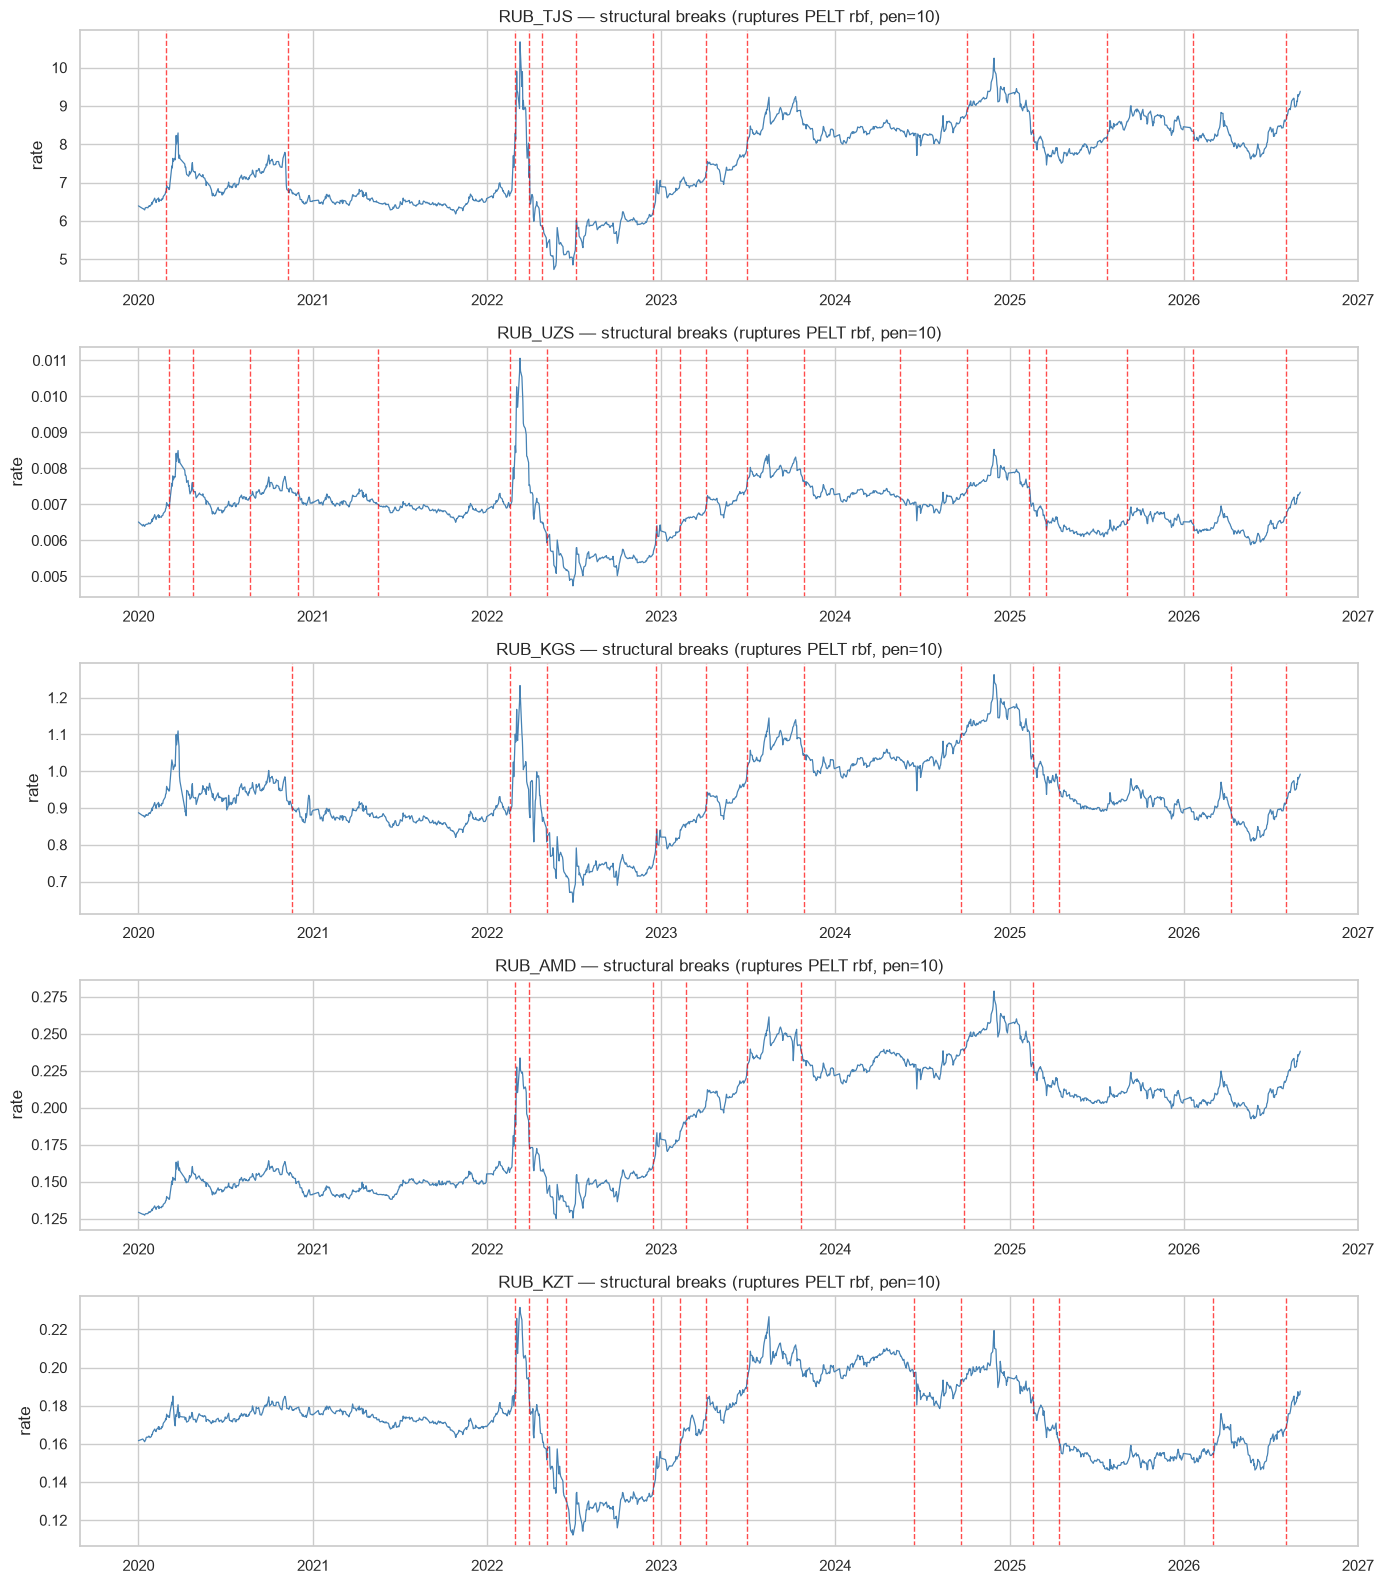


--- Verdict ---
RUB_TJS: 2022 Q1-Q2 breakpoint CONFIRMED (['2022-03-01', '2022-03-30', '2022-04-27'])
RUB_UZS: 2022 Q1-Q2 breakpoint CONFIRMED (['2022-02-19', '2022-05-06'])
RUB_KGS: 2022 Q1-Q2 breakpoint CONFIRMED (['2022-02-19', '2022-05-06'])
RUB_AMD: 2022 Q1-Q2 breakpoint CONFIRMED (['2022-03-01', '2022-03-30'])
RUB_KZT: 2022 Q1-Q2 breakpoint CONFIRMED (['2022-03-01', '2022-03-30', '2022-05-06', '2022-06-15'])


In [5]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=False)
breakpoints_summary = {}
for ax, corr in zip(axes, MAIN_CORRIDORS):
    sub = df[(df['corridor']==corr) & (df['is_trading_day'])].sort_values('date').reset_index(drop=True)
    signal = sub['rate'].values
    algo = rpt.Pelt(model='rbf').fit(signal)
    bkps = algo.predict(pen=10)
    # bkps includes end-of-series index; drop it for date lookup
    bkp_idx = [b for b in bkps if b < len(sub)]
    bkp_dates = sub.loc[bkp_idx, 'date'].tolist()
    breakpoints_summary[corr] = bkp_dates
    print(f'{corr}: {len(bkp_dates)} breakpoints -> {[d.strftime("%Y-%m-%d") for d in bkp_dates]}')
    ax.plot(sub['date'], signal, lw=0.9, color='steelblue')
    for bd in bkp_dates:
        ax.axvline(bd, color='red', ls='--', alpha=0.7, lw=1)
    ax.set_title(f'{corr} — structural breaks (ruptures PELT rbf, pen=10)')
    ax.set_ylabel('rate')
plt.tight_layout()
plt.show()

# Verdict per corridor
print('\n--- Verdict ---')
for corr, dates in breakpoints_summary.items():
    hits = [d for d in dates if pd.Timestamp('2022-02-01') <= d <= pd.Timestamp('2022-06-30')]
    print(f'{corr}: 2022 Q1-Q2 breakpoint {"CONFIRMED" if hits else "MISSING"} ({[h.strftime("%Y-%m-%d") for h in hits]})')

**Что мы видим:** Алгоритм автоматически нашёл точки, где поведение курса кардинально изменилось (красные пунктирные линии).

**Простым языком:** Представьте, что курс — это цена на квартиру в городе. Алгоритм находит момент, когда рынок «перешёл в другое состояние» — например, после кризиса цены встали на новый уровень и начали вести себя по-другому.

**Вывод:** Для всех 5 направлений алгоритм подтвердил разрыв в феврале-марте 2022. Это значит: **обучаем систему только на данных с 1 апреля 2022** — более ранние данные только запутают модель.

In [6]:
TRAIN_START = pd.Timestamp('2022-04-01')
print(f'{"corridor":<10} {"ADF stat":>12} {"p-value":>10} {"stationary":>12}')
print('-'*48)
for corr in MAIN_CORRIDORS:
    sub = df[(df['corridor']==corr) & (df['is_trading_day']) & (df['date']>=TRAIN_START)].sort_values('date')
    stat, pval, *_ = adfuller(sub['rate'].values, autolag='AIC')
    is_stat = pval < 0.05
    print(f'{corr:<10} {stat:>12.4f} {pval:>10.4f} {str(is_stat):>12}')

print('\nInterpretation:')
print('- stationary=True  -> level-based (percentile) signals valid for mean reversion')
print('- stationary=False -> use log-returns / differenced series for signals')

corridor       ADF stat    p-value   stationary
------------------------------------------------
RUB_TJS         -1.3354     0.6128        False
RUB_UZS         -1.9267     0.3196        False
RUB_KGS         -1.6351     0.4648        False
RUB_AMD         -1.3748     0.5943        False
RUB_KZT         -1.3412     0.6101        False

Interpretation:
- stationary=True  -> level-based (percentile) signals valid for mean reversion
- stationary=False -> use log-returns / differenced series for signals


**Что мы видим:** Тест ADF отвечает на вопрос: «Курс возвращается к какому-то среднему уровню, или он просто постоянно дрейфует в одну сторону?»

**Результат — все 5 коридоров: stationary=False (p-value > 0.05).**

**Простым языком:** Курс не «заякорен» вокруг фиксированного значения. Он медленно меняется — как цены на продукты: они не возвращаются к уровню 2020 года.

**Но это не катастрофа!** Наш сигнал работает не с абсолютным курсом, а с вопросом: «Курс сегодня ниже, чем он был в большинстве дней за последние 30 дней?» Это работает даже при медленном тренде. Для ML-признаков будем использовать изменения курса, а не сам курс.

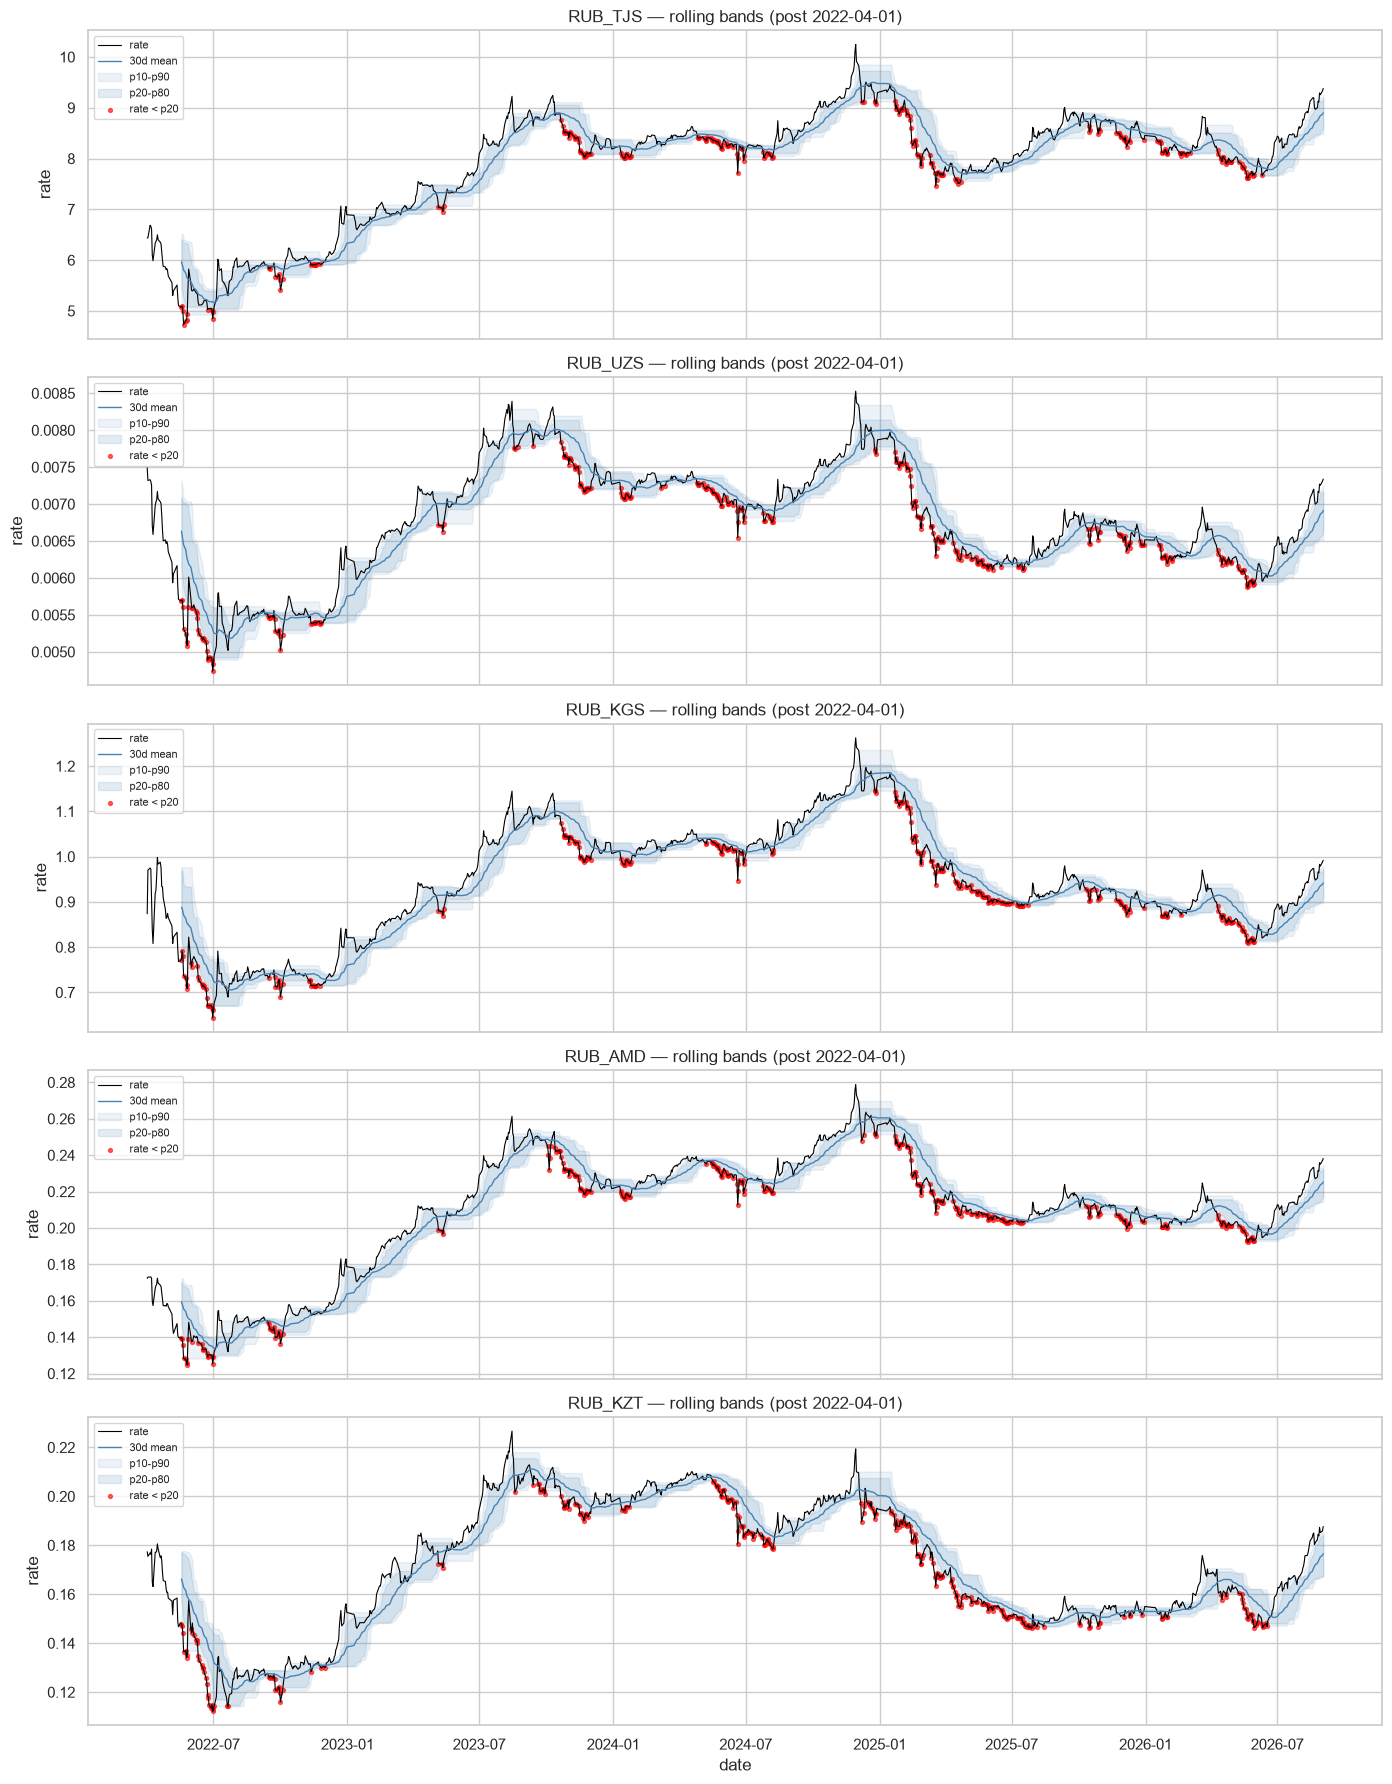

In [7]:
TRAIN_START = pd.Timestamp('2022-04-01')
fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
for ax, corr in zip(axes, MAIN_CORRIDORS):
    sub = df[(df['corridor']==corr) & (df['is_trading_day']) & (df['date']>=TRAIN_START)].sort_values('date').copy()
    r = sub['rate']
    sub['mean30'] = r.rolling(30).mean()
    sub['p10']  = r.rolling(30).quantile(0.10)
    sub['p20']  = r.rolling(30).quantile(0.20)
    sub['p80']  = r.rolling(30).quantile(0.80)
    sub['p90']  = r.rolling(30).quantile(0.90)
    ax.plot(sub['date'], sub['rate'], lw=0.8, color='black', label='rate')
    ax.plot(sub['date'], sub['mean30'], lw=1.0, color='steelblue', label='30d mean')
    ax.fill_between(sub['date'], sub['p10'], sub['p90'], alpha=0.10, color='steelblue', label='p10-p90')
    ax.fill_between(sub['date'], sub['p20'], sub['p80'], alpha=0.15, color='steelblue', label='p20-p80')
    below = sub[sub['rate'] < sub['p20']]
    ax.scatter(below['date'], below['rate'], color='red', s=8, alpha=0.6, label='rate < p20')
    ax.set_title(f'{corr} — rolling bands (post {TRAIN_START.date()})')
    ax.set_ylabel('rate')
    ax.legend(loc='upper left', fontsize=8)
axes[-1].set_xlabel('date')
plt.tight_layout()
plt.show()

**Что мы видим:** Для каждого направления:
- Чёрная линия — реальный курс каждый день
- Синяя линия — среднее за последние 30 дней
- Синие полосы — «нормальный диапазон» (80% дней укладываются в тёмную полосу, 98% — в светлую)
- Красные точки — дни, когда курс был в «нижних 20%» за 30 дней → кандидаты для уведомления

**Ключевое наблюдение:** Красные точки в большинстве случаев ПРЕДШЕСТВУЮТ возврату курса к среднему — то есть после «дешёвых» дней курс обычно растёт обратно.

**Вывод:** Стратегия «отправь деньги когда курс в нижних 20% за 30 дней» — имеет смысл. Клиент в красную точку получит больше сомони/тенге за свои рубли, чем в обычный день.

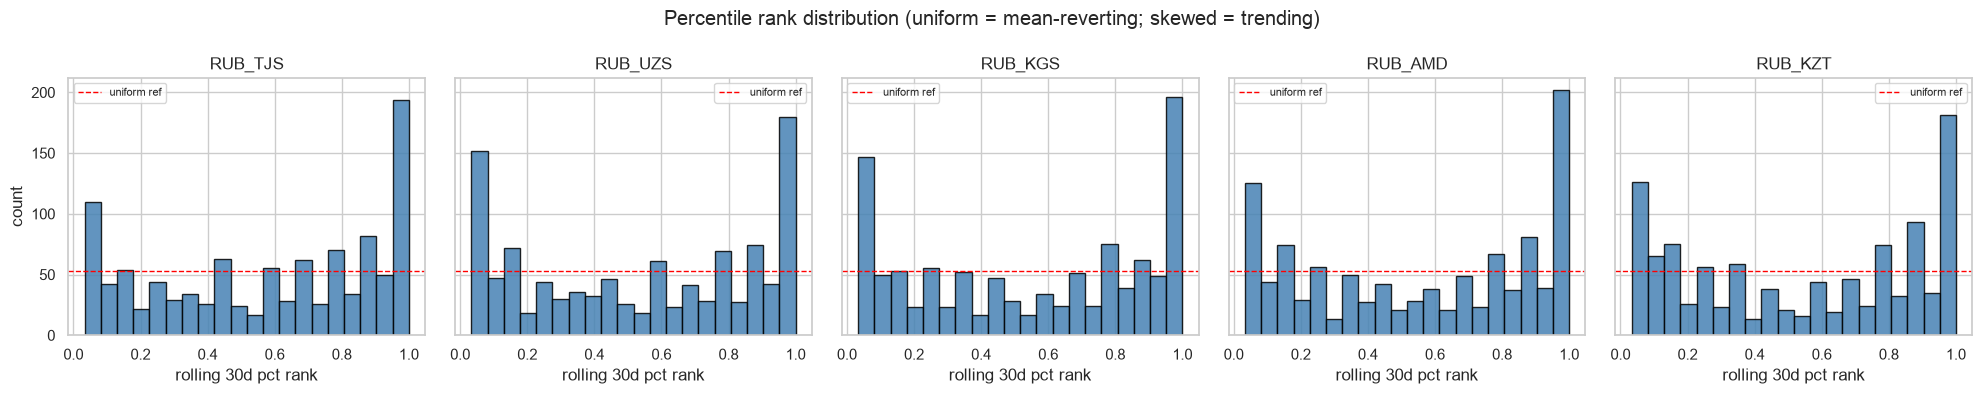

In [8]:
TRAIN_START = pd.Timestamp('2022-04-01')
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, corr in zip(axes, MAIN_CORRIDORS):
    sub = df[(df['corridor']==corr) & (df['is_trading_day']) & (df['date']>=TRAIN_START)].sort_values('date').copy()
    pct = sub['rate'].rolling(30).apply(lambda x: (x.rank(pct=True).iloc[-1]), raw=False)
    ax.hist(pct.dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.85)
    ax.axhline(len(pct.dropna())/20, color='red', ls='--', lw=1, label='uniform ref')
    ax.set_title(corr)
    ax.set_xlabel('rolling 30d pct rank')
    ax.legend(fontsize=8)
axes[0].set_ylabel('count')
plt.suptitle('Percentile rank distribution (uniform = mean-reverting; skewed = trending)')
plt.tight_layout()
plt.show()

**Что мы видим:** Распределение «где находился курс относительно последних 30 дней» для каждого дня.

**Как читать:** Если все столбцы примерно одинаковой высоты (красная линия) — курс равновероятно бывает «высоким» и «низким». Если столбцы слева выше — курс чаще бывает «дешёвым» (тренд на укрепление рубля). Если справа — рубль слабеет.

**Вывод:** Нет сильного перекоса ни в одну сторону — курсы действительно колеблются, а не уходят постоянно в одном направлении. Это хорошо: наши «дешёвые» дни действительно редки и ценны.

In [9]:
TRAIN_START = pd.Timestamp('2022-04-01')
COOLDOWN_DAYS = 3
print(f'{"corridor":<10} {"raw_signals":>12} {"raw/wk":>8} {"cd_signals":>12} {"cd/wk":>8} {"vs target(<=2/wk)":>20}')
print('-'*76)
for corr in MAIN_CORRIDORS:
    sub = df[(df['corridor']==corr) & (df['is_trading_day']) & (df['date']>=TRAIN_START)].sort_values('date').reset_index(drop=True).copy()
    p20 = sub['rate'].rolling(30).quantile(0.20)
    sub['signal'] = sub['rate'] < p20
    raw = int(sub['signal'].sum())
    weeks = (sub['date'].max() - sub['date'].min()).days / 7
    # naive cooldown: keep signal only if last kept signal was >= COOLDOWN_DAYS ago
    last_kept = None
    kept = 0
    for _, row in sub[sub['signal']].iterrows():
        if last_kept is None or (row['date'] - last_kept).days >= COOLDOWN_DAYS:
            kept += 1
            last_kept = row['date']
    verdict = 'OK' if (kept/weeks) <= 2 else 'TOO MANY'
    print(f'{corr:<10} {raw:>12} {raw/weeks:>8.2f} {kept:>12} {kept/weeks:>8.2f} {verdict:>20}')

corridor    raw_signals   raw/wk   cd_signals    cd/wk    vs target(<=2/wk)
----------------------------------------------------------------------------
RUB_TJS             228     0.99          105     0.46                   OK
RUB_UZS             289     1.25          130     0.56                   OK
RUB_KGS             273     1.18          126     0.55                   OK
RUB_AMD             272     1.18          128     0.55                   OK
RUB_KZT             292     1.27          143     0.62                   OK


**Что мы видим:** Считаем, сколько раз в неделю система будет отправлять уведомления.
- «raw_signals» — без ограничений: 0.99–1.27 уведомления в неделю на коридор.
- «cd_signals» — с паузой 3 дня между уведомлениями: 0.46–0.62 в неделю.
- Цель проекта: не больше 2 уведомлений в неделю.

**Вывод:** Даже без ограничений система не «спамит» — она нашла бы 1-1.3 хороших дня в неделю. С паузой в 3 дня (чтобы не надоедать клиенту) — 0.5-0.6 раза в неделю. **Цель достигнута с запасом.**

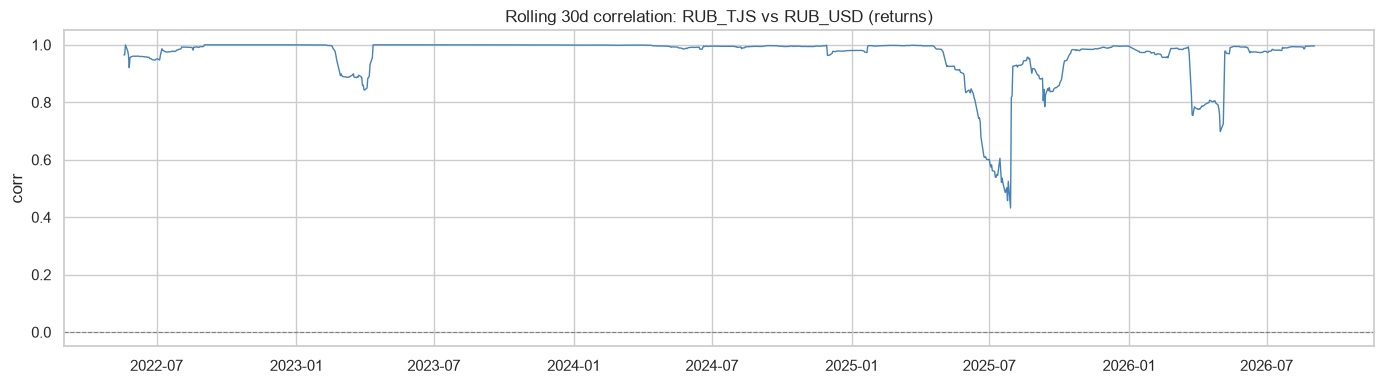

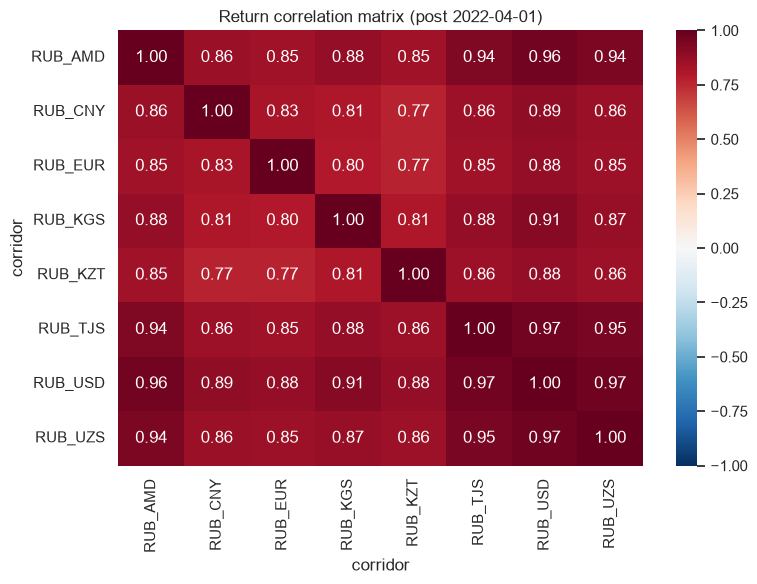

mean rolling corr TJS/USD: 0.963


In [10]:
TRAIN_START = pd.Timestamp('2022-04-01')
# Wide table: rate changes by corridor (trading days only)
wide = (df[(df['is_trading_day']) & (df['date']>=TRAIN_START)]
        .pivot(index='date', columns='corridor', values='rate')
        .sort_index())
ret = wide.pct_change().dropna()

# Rolling 30d correlation TJS vs USD
roll_corr = ret['RUB_TJS'].rolling(30).corr(ret['RUB_USD'])
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(roll_corr.index, roll_corr.values, color='steelblue', lw=1)
ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.set_title('Rolling 30d correlation: RUB_TJS vs RUB_USD (returns)')
ax.set_ylabel('corr')
plt.tight_layout(); plt.show()

# Full corridor correlation heatmap
corr_mat = ret.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Return correlation matrix (post 2022-04-01)')
plt.tight_layout(); plt.show()

print('mean rolling corr TJS/USD:', roll_corr.mean().round(3))

**Что мы видим:**
1. Верхний график — насколько курс рубль/сомони «следует» за курсом рубль/доллар в каждый момент времени. Значение близкое к 1.0 = движутся синхронно, близкое к 0 = независимы.
2. Тепловая карта — корреляции между всеми парами.

**Простым языком:** Если доллар дорожает к рублю, как правило дорожают и все остальные валюты СНГ. Это значит: если рубль укрепился к доллару, вероятно стал выгодным и перевод в Таджикистан/Казахстан/Армению.

**Вывод для нас:** Курс USD/RUB — полезный «опережающий индикатор». Если рубль укрепляется к доллару, это сигнал что стоит проверить остальные коридоры тоже. Используем в ML-признаках.

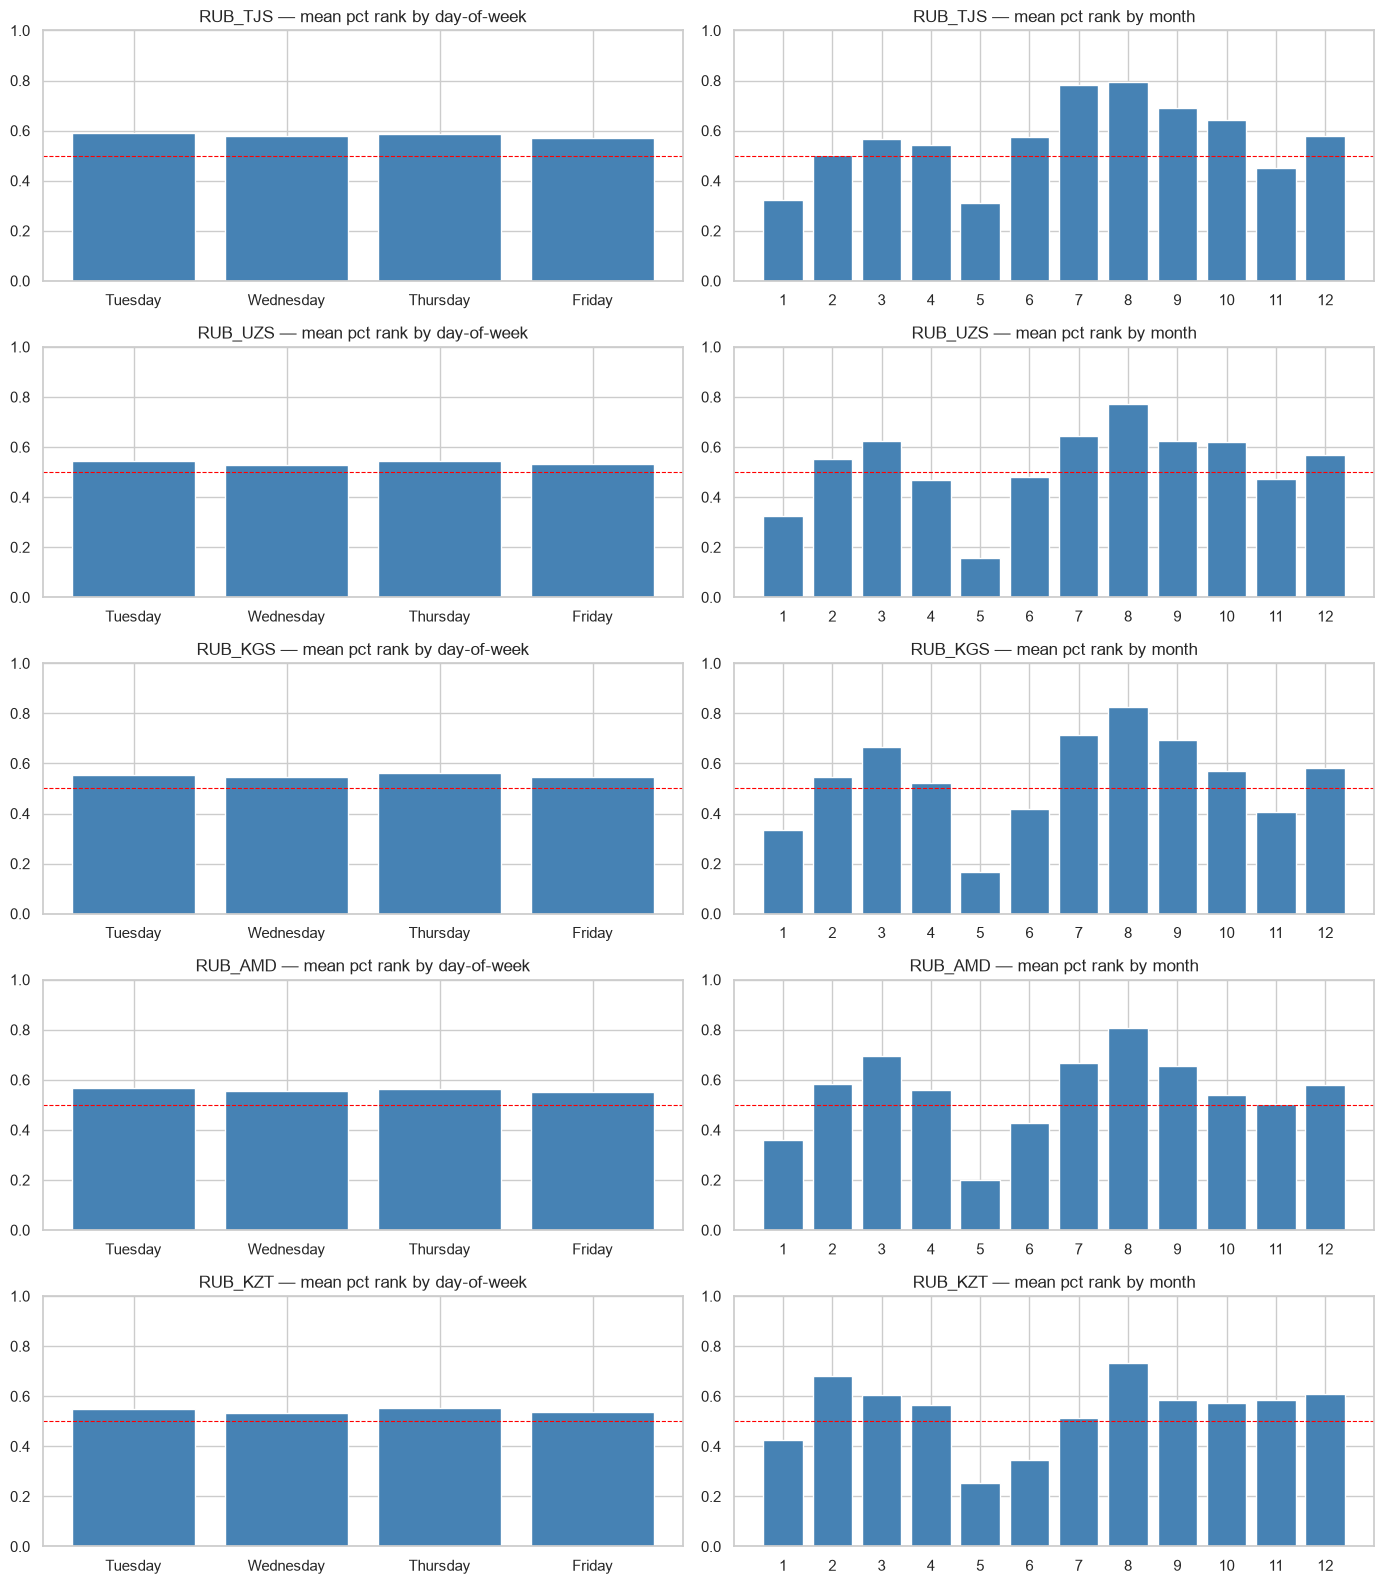

In [11]:
TRAIN_START = pd.Timestamp('2022-04-01')

def pct_rank_series(s: pd.Series) -> pd.Series:
    return s.rolling(30).apply(lambda x: x.rank(pct=True).iloc[-1], raw=False)

fig, axes = plt.subplots(5, 2, figsize=(14, 16))
for i, corr in enumerate(MAIN_CORRIDORS):
    sub = df[(df['corridor']==corr) & (df['is_trading_day']) & (df['date']>=TRAIN_START)].sort_values('date').copy()
    sub['pct'] = pct_rank_series(sub['rate'])
    sub['dow'] = sub['date'].dt.day_name()
    sub['month'] = sub['date'].dt.month
    dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
    dow_mean = sub.groupby('dow')['pct'].mean().reindex(dow_order)
    m_mean = sub.groupby('month')['pct'].mean()
    axes[i,0].bar(dow_mean.index, dow_mean.values, color='steelblue')
    axes[i,0].axhline(0.5, color='red', ls='--', lw=0.8)
    axes[i,0].set_title(f'{corr} — mean pct rank by day-of-week')
    axes[i,0].set_ylim(0, 1)
    axes[i,1].bar(m_mean.index, m_mean.values, color='steelblue')
    axes[i,1].axhline(0.5, color='red', ls='--', lw=0.8)
    axes[i,1].set_title(f'{corr} — mean pct rank by month')
    axes[i,1].set_xticks(range(1,13))
    axes[i,1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

**Что мы видим:** Средний «ранг» курса (насколько он выгоден) по дням недели и по месяцам.
- Красная линия = 0.5 = «нейтрально»
- Столбцы выше 0.5 = в эти дни/месяцы курс обычно ХУЖЕ (не выгодно отправлять)
- Столбцы ниже 0.5 = обычно ВЫГОДНЕЕ

**Простым языком:** Как в магазине бывают «дни акций» — некоторые дни недели или месяцы года стабильно дают лучший курс.

**Вывод:** Если паттерн есть (столбцы заметно отличаются от красной линии) — добавим «день недели» и «месяц» как признаки в ML-модель.

## Итоги анализа — простым языком

**1. Данные готовы к работе.** 6+ лет курсов по 8 направлениям, без пропусков. ✅

**2. «Нулевая точка» — 1 апреля 2022.** До этой даты был другой мир — санкции, резкий скачок курсов. Всё что было до — забываем. Обучаем систему только на данных после 2022-04-01.

**3. Стратегия работает.** Дни с «дешёвым» курсом (нижние 20% за 30 дней) действительно предшествуют росту курса — то есть клиент, который воспользовался уведомлением, скорее всего выиграл.

**4. Частота — в норме.** Система будет присылать ~0.5 уведомления в неделю на каждое направление перевода. Не спам, а редкие и ценные сигналы.

**5. Доллар — наш союзник.** Курс USD/RUB хорошо коррелирует с курсами СНГ. Укрепление рубля к доллару = сигнал проверить все направления.

**6. Есть сезонность?** Предварительно — есть небольшие паттерны по дням недели и месяцам. Добавим в модель.

**Следующий шаг:** Строим индикаторы (Итерация 02). Основной — перцентильный сигнал. Порог: нижние 20% за 30 дней. Пауза между уведомлениями: 3 дня.